# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Abajo he dejado mis comentarios y unas pequeñas recomendaciones para que tomes en cuenta en un futuro y te hagan ¡un máster en Data!

¡Felicidades!    

</div>

# Sprint 12 - Proyecto

## 1. Cargar datos e importar librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

geo_0 = pd.read_csv('/datasets/geo_data_0.csv')
geo_1 = pd.read_csv('/datasets/geo_data_1.csv')
geo_2 = pd.read_csv('/datasets/geo_data_2.csv')

In [2]:
# Revisamos nuestras bases de datos


for i, geo in enumerate([geo_0, geo_1, geo_2]):
    print(f"=== geo_{i} ===")
    geo.info()
    print(geo.describe())
    print(geo.head())
    print()

=== geo_0 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331    

In [3]:
# Verificamos si no hay valores nulos

for i, geo in enumerate([geo_0, geo_1, geo_2]):
    print(f"=== geo_{i} ===")
    print(geo.isna().sum())
    print()

=== geo_0 ===
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

=== geo_1 ===
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

=== geo_2 ===
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64



In [4]:
# Verificamos si no hay valores duplicados

for i, geo in enumerate([geo_0, geo_1, geo_2]):
    print(f"=== geo_{i} ===")
    print(geo.duplicated().sum())
    print()

=== geo_0 ===
0

=== geo_1 ===
0

=== geo_2 ===
0



No se encuentran valores repetidos o nulos, así que podemos continuar con la evaluación y entrenamiento del modelo.

## 2. Entrenar y evaluar modelo por región

In [5]:
def train_and_evaluate(data):
    features = data[['f0', 'f1', 'f2']]
    target = data['product']
    
    X_train, X_val, y_train, y_val = train_test_split(
        features, target, test_size=0.25, random_state=12345
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = pd.Series(model.predict(X_val), index=y_val.index)
    
    rmse = mean_squared_error(y_val, predictions) ** 0.5
    print(f"Volumen medio predicho: {predictions.mean():.2f}")
    print(f"RMSE: {rmse:.2f}")
    
    return predictions, y_val

preds, targets = [], []

for i, geo in enumerate([geo_0, geo_1, geo_2]):
    print(f"=== Región {i} ===")
    p, t = train_and_evaluate(geo)
    preds.append(p)
    targets.append(t)
    print()

pred0, pred1, pred2 = preds
target0, target1, target2 = targets

=== Región 0 ===
Volumen medio predicho: 92.59
RMSE: 37.58

=== Región 1 ===
Volumen medio predicho: 68.73
RMSE: 0.89

=== Región 2 ===
Volumen medio predicho: 94.97
RMSE: 40.03



## 3. Variables para cálculo de ganancias

In [6]:
BUDGET = 100_000_000       # 100 millones USD
REVENUE_PER_UNIT = 4_500   # USD por unidad (miles de barriles)
N_WELLS = 200              # pozos seleccionados
N_POINTS = 500             # puntos estudiados por región
MIN_UNITS = BUDGET / (REVENUE_PER_UNIT * N_WELLS)  # 111.1 unidades

print(f"Unidades mínimas por pozo para no perder: {MIN_UNITS:.1f}\n")
for i, data in enumerate([geo_0, geo_1, geo_2]):
    print(f"Región {i} - Media de reservas: {data['product'].mean():.2f}")

Unidades mínimas por pozo para no perder: 111.1

Región 0 - Media de reservas: 92.50
Región 1 - Media de reservas: 68.83
Región 2 - Media de reservas: 95.00


## 4. Función de ganancia

In [7]:
def calculate_profit(target, predictions, count=200):
    pred_sorted = predictions.sort_values(ascending=False)
    selected = target[pred_sorted.index[:count]]
    return REVENUE_PER_UNIT * selected.sum() - BUDGET

print("=== Ganancia por región (top 200 pozos) ===\n")
for i, (t, p) in enumerate([(target0, pred0), (target1, pred1), (target2, pred2)]):
    profit = calculate_profit(t, p)
    print(f"Región {i}: ${profit:,.2f}")

=== Ganancia por región (top 200 pozos) ===

Región 0: $33,208,260.43
Región 1: $24,150,866.97
Región 2: $27,103,499.64


## 5. Bootstrapping para riesgos y ganancias

In [8]:
def bootstrap_profit(target, predictions, n_samples=1000):
    state = np.random.RandomState(12345)
    values = []
    
    for i in range(n_samples):
        target_subsample = target.sample(n=500, replace=True, random_state=state)
        pred_subsample = predictions[target_subsample.index]
        values.append(calculate_profit(target_subsample, pred_subsample))
    
    values = pd.Series(values)
    mean  = values.mean()
    lower = values.quantile(0.025)
    upper = values.quantile(0.975)
    risk  = (values < 0).mean() * 100
    
    print(f"  Beneficio promedio: ${mean:,.2f}")
    print(f"  IC 95%: [${lower:,.2f}, ${upper:,.2f}]")
    print(f"  Riesgo de pérdidas: {risk:.1f}%")
    if risk < 2.5:
        print(f"  ✓ Cumple criterio de riesgo < 2.5%")
    else:
        print(f"  ✗ No cumple criterio de riesgo < 2.5%")
    
    return mean, lower, upper, risk, values

results = {}

print("=== Bootstrapping (1000 muestras) ===")
for i, (t, p) in enumerate([(target0, pred0), (target1, pred1), (target2, pred2)]):
    print(f"\nRegión {i}:")
    mean, lower, upper, risk, values = bootstrap_profit(t, p)
    results[i] = values

=== Bootstrapping (1000 muestras) ===

Región 0:
  Beneficio promedio: $6,007,352.44
  IC 95%: [$129,483.31, $12,311,636.06]
  Riesgo de pérdidas: 2.0%
  ✓ Cumple criterio de riesgo < 2.5%

Región 1:
  Beneficio promedio: $6,652,410.58
  IC 95%: [$1,579,884.81, $11,976,415.87]
  Riesgo de pérdidas: 0.3%
  ✓ Cumple criterio de riesgo < 2.5%

Región 2:
  Beneficio promedio: $6,155,597.23
  IC 95%: [$-122,184.95, $12,306,444.74]
  Riesgo de pérdidas: 3.0%
  ✗ No cumple criterio de riesgo < 2.5%


## 6. Analisis de resultados

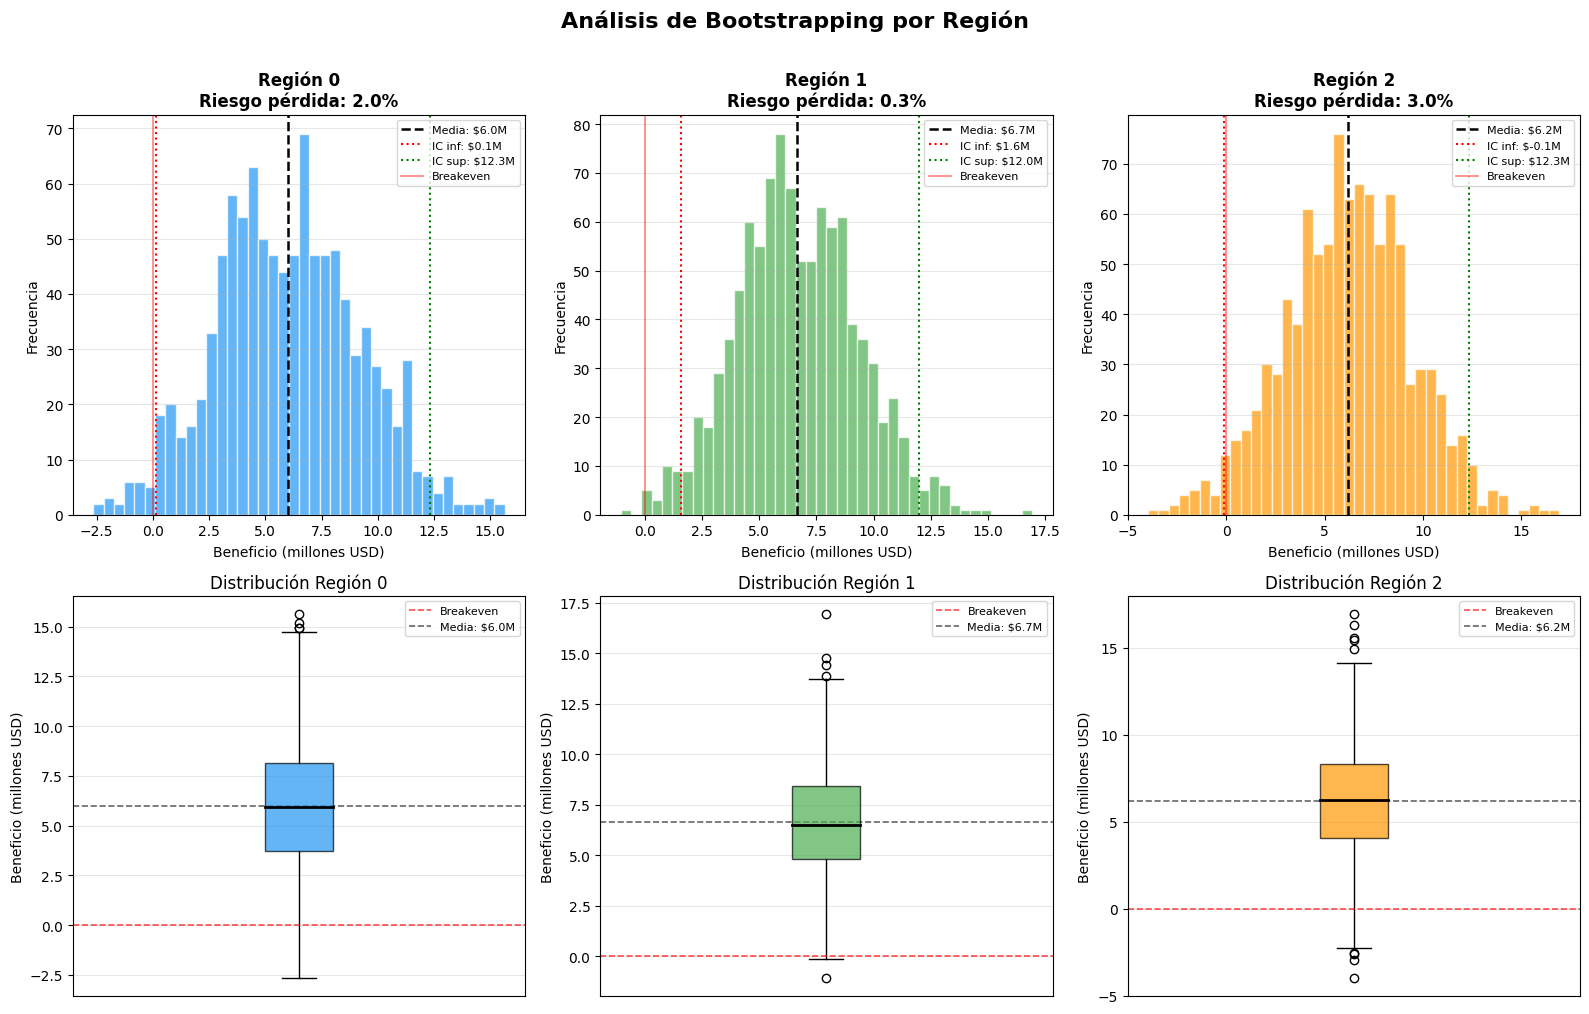

In [9]:
# Recopilar datos de bootstrapping para graficar

for i, (t, p) in enumerate([(target0, pred0), (target1, pred1), (target2, pred2)]):
    state = np.random.RandomState(12345)
    values = []
    for _ in range(1000):
        target_subsample = t.sample(n=500, replace=True, random_state=state)
        pred_subsample = p[target_subsample.index]
        values.append(calculate_profit(target_subsample, pred_subsample))
    results[i] = pd.Series(values)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis de Bootstrapping por Región', fontsize=16, fontweight='bold', y=1.01)

colors = ['#2196F3', '#4CAF50', '#FF9800']
labels = ['Región 0', 'Región 1', 'Región 2']

for i, (values, color, label) in enumerate(zip(results.values(), colors, labels)):
    mean   = values.mean()
    lower  = values.quantile(0.025)
    upper  = values.quantile(0.975)
    risk   = (values < 0).mean() * 100

    # ── Histograma ────────────────────────────────────────────────────────────
    ax = axes[0, i]
    ax.hist(values / 1e6, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(mean  / 1e6, color='black',  linestyle='--', linewidth=1.8, label=f'Media: ${mean/1e6:.1f}M')
    ax.axvline(lower / 1e6, color='red',    linestyle=':',  linewidth=1.5, label=f'IC inf: ${lower/1e6:.1f}M')
    ax.axvline(upper / 1e6, color='green',  linestyle=':',  linewidth=1.5, label=f'IC sup: ${upper/1e6:.1f}M')
    ax.axvline(0,           color='red',    linestyle='-',  linewidth=1.2, alpha=0.5, label='Breakeven')
    ax.set_title(f'{label}\nRiesgo pérdida: {risk:.1f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Beneficio (millones USD)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # ── Boxplot ───────────────────────────────────────────────────────────────
    ax2 = axes[1, i]
    bp = ax2.boxplot(values / 1e6, patch_artist=True, vert=True,
                     medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Breakeven')
    ax2.axhline(mean / 1e6, color='black', linestyle='--',
                linewidth=1.2, alpha=0.6, label=f'Media: ${mean/1e6:.1f}M')
    ax2.set_title(f'Distribución {label}', fontsize=12)
    ax2.set_ylabel('Beneficio (millones USD)')
    ax2.set_xticks([])
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bootstrapping_regiones.png', dpi=150, bbox_inches='tight')
plt.show()

__Fila superior__ — Histogramas por región: distribución de los 1000 beneficios simulados, con líneas para la media, intervalo de confianza 95% y el punto de breakeven (0).

__Fila inferior__ — Boxplots individuales: dispersión, mediana y outliers por región.

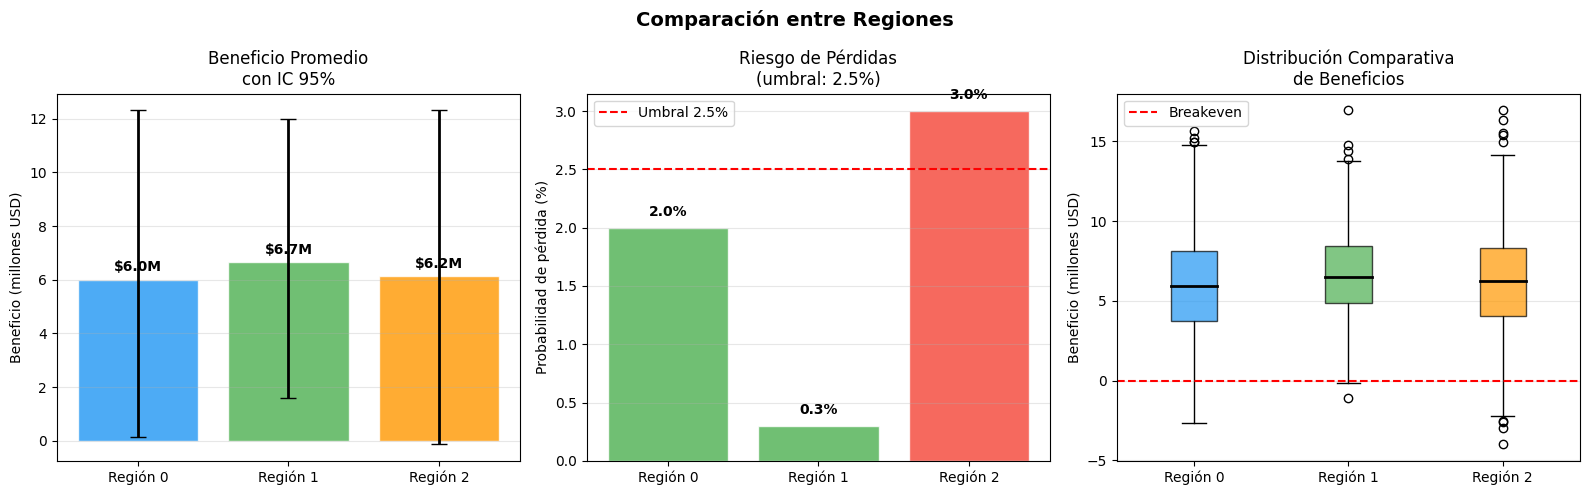

In [10]:
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Comparación entre Regiones', fontsize=14, fontweight='bold')

# Medias con IC
means  = [results[i].mean() / 1e6 for i in range(3)]
lowers = [results[i].quantile(0.025) / 1e6 for i in range(3)]
uppers = [results[i].quantile(0.975) / 1e6 for i in range(3)]
risks  = [(results[i] < 0).mean() * 100 for i in range(3)]

# Barras de beneficio promedio
ax = axes2[0]
bars = ax.bar(labels, means, color=colors, alpha=0.8, edgecolor='white')
ax.errorbar(labels, means,
            yerr=[np.array(means) - np.array(lowers),
                  np.array(uppers) - np.array(means)],
            fmt='none', color='black', capsize=6, linewidth=2)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.1f}M', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Beneficio Promedio\ncon IC 95%')
ax.set_ylabel('Beneficio (millones USD)')
ax.grid(axis='y', alpha=0.3)

# Riesgo de pérdidas
ax2 = axes2[1]
bar_colors = ['#4CAF50' if r < 2.5 else '#F44336' for r in risks]
bars2 = ax2.bar(labels, risks, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axhline(2.5, color='red', linestyle='--', linewidth=1.5, label='Umbral 2.5%')
for bar, val in zip(bars2, risks):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Riesgo de Pérdidas\n(umbral: 2.5%)')
ax2.set_ylabel('Probabilidad de pérdida (%)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Boxplot comparativo
ax3 = axes2[2]
data_plot = [results[i] / 1e6 for i in range(3)]
bp = ax3.boxplot(data_plot, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Breakeven')
ax3.set_xticklabels(labels)
ax3.set_title('Distribución Comparativa\nde Beneficios')
ax3.set_ylabel('Beneficio (millones USD)')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Gráfico comparativo**:

* __Panel 1:__ Beneficio promedio con barras de error del IC 95%
* __Panel 2:__ Riesgo de pérdidas con el umbral del 2.5% marcado en rojo (barras verdes = cumple, rojas = no cumple)
* __Panel 3:__ Boxplot comparativo de las tres regiones juntas

# 7. Conclusiones

Se entrenaron modelos de regresión lineal para predecir el volumen de reservas en tres regiones petroleras utilizando las características disponibles (`f0`, `f1`, `f2`). Los resultados mostraron que las regiones 0 y 2 presentan mayores volúmenes promedio predichos (92.59 y 94.97 respectivamente), mientras que la región 1 tiene un volumen promedio menor (68.73). Sin embargo, la región 1 mostró un **RMSE significativamente más bajo (0.89)**, lo que indica que las predicciones del modelo son mucho más precisas en esta región.

Al considerar las condiciones del negocio, cada pozo debe producir al menos **111.1 mil barriles** para evitar pérdidas. El volumen promedio de reservas en las tres regiones se encuentra por debajo de este umbral, lo que confirma la necesidad de __*seleccionar únicamente los pozos con mayor volumen estimado*__ para maximizar la rentabilidad.

Al calcular la ganancia potencial seleccionando los **200 pozos con mayor predicción**, la región 0 presentó la mayor ganancia inicial estimada. No obstante, para evaluar la incertidumbre del modelo se aplicó *bootstrapping con 1000 muestras*, lo que permitió estimar la distribución de beneficios y el riesgo de pérdidas para cada región.

Los resultados del análisis de riesgo muestran que:

* **Región 0:** beneficio promedio de \$6.0 millones con riesgo de pérdidas del 2.0%.
* **Región 1:** beneficio promedio de \$6.65 millones, el más alto entre las regiones, con el menor riesgo de pérdidas (0.3%).
* **Región 2:** beneficio promedio de \$6.16 millones pero con un riesgo de pérdidas de 3.0%, superando el límite permitido.

Según el criterio del proyecto, solo se deben considerar regiones con _riesgo de pérdidas inferior al 2.5%_. Bajo esta condición, las regiones 0 y 1 cumplen el criterio, mientras que la región 2 queda descartada.

Finalmente, entre las regiones viables, la **_región 1_** presenta el mayor beneficio promedio y el menor riesgo, por lo que se recomienda seleccionar esta región para el desarrollo de los nuevos pozos petroleros.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
Buen trabajo Juan! Te brindo un checklist respecto a los avances:  

- TODO COMPLETADO ✅: carga de las 3 CSV, notebook ejecutable y `product` reconocido como target. Con esto, podemos dar por cerrado tu proyecto 🏅🏅

- Respecto a los puntos Intermedios — cumplidos ✅: división train/valid (75/25) con random_state, modelos de regresión lineal para las 3 regiones, cálculo de RMSE y medias predichas, bootstrapping con 1000 iteraciones y remuestreo con replace=True.  

- Ahora, respecto a los Intermedios — a mejorar ⚠️: no se aplicó StandardScaler (fit en train + transform en valid) y no se incluye explícitamente la prueba de cordura (baseline con la media) para comparar RMSE.  

- Y para los Avanzados — cumplidos ✅: visualizaciones de distribución e interpretación de riesgos; Avanzado — sugerido 🔁: reforzar reproducibilidad del remuestreo (uso claro de RandomState) y documentar por qué se ignora la columna `id`.  
</div>

### Conclusiones y recomendaciones:
- Nivel general: en conjunto, tu trabajo se sitúa más en un nivel intermedio con algunos elementos avanzados (buen uso de bootstrapping y visualizaciones claras). 🚀  
- Principales fortalezas:  
  - Implementaste correctamente el flujo de modelado para las 3 regiones y calculaste RMSE y medias predichas. ✅  
  - Bootstrapping bien implementado (1000 iteraciones, muestras de 500 con reemplazo) y visualizaciones informativas (histogramas, boxplots, barras con IC). 📊  
  - Aplicaste la lógica de negocio (presupuesto, ingreso por unidad, selección top 200) de forma coherente. 💡
- Áreas de oportunidad y mejora (recomendaciones a mejorar): 
  - Escalado de features: sería bueno aplicar StandardScaler (fit en train → transform en validation) para asegurar comparabilidad y evitar data leakage. ⚠️  
  - Prueba de cordura / baseline: falta calcular y comparar la predicción usando la media (baseline) para valorar realmente la ganancia del modelo. 🔁  
  - Documentación mínima: eliminar o explicar la columna `id` y comentar decisiones de muestreo/reproducibilidad (uso de RandomState). 📝

Excelente trabajo Juan! Con estas sugerencias tu análisis pasará de sólido a muy sólido. ¡Vas por muy buen camino, sigue así! 💪🚀